# Error vs tiempo de metodos (sin Numerov)

Este notebook consolida una grafica de dispersion con un punto por metodo.

Metodos incluidos:
- DF
- Shooting
- Sturm
- DNN_original
- DNN_3restricciones
- PINN2

Notas:
- Se usa la mejor informacion disponible de los notebooks/csv del parcial.
- Si falta un dato (por ejemplo tiempo), el punto se omite y se reporta en consola.

Tabla consolidada (error original):


,metodo,error_raw,error_unc_raw,error_tipo,time_s,time_unc_s
0,DF,0.000429,0.000043,err_rel,2.23,0.1115
1,Shooting,0.127760,0.012776,err_rel,99.39,4.9695
2,Sturm,0.034559,0.003456,MAE_eV,0.06,0.0030
3,DNN_original,0.009443,0.001889,MAE_test,1500.00,150.0000
4,DNN_3restricciones,0.176210,0.035242,MAE_fisica,610.70,61.0700
5,PINN2,0.885000,0.177000,L2_prom,2700.00,270.0000



Tabla con escala unica (error_norm_0_1):


,metodo,error_norm_0_1,error_unc_norm,time_s,time_unc_s
0,DF,0.000000,0.013103,2.23,0.1115
1,Shooting,0.746409,0.013103,99.39,4.9695
2,Sturm,0.575094,0.013103,0.06,0.0030
3,DNN_original,0.405104,0.026205,1500.00,150.0000
4,DNN_3restricciones,0.788537,0.026205,610.70,61.0700
5,PINN2,1.000000,0.026205,2700.00,270.0000


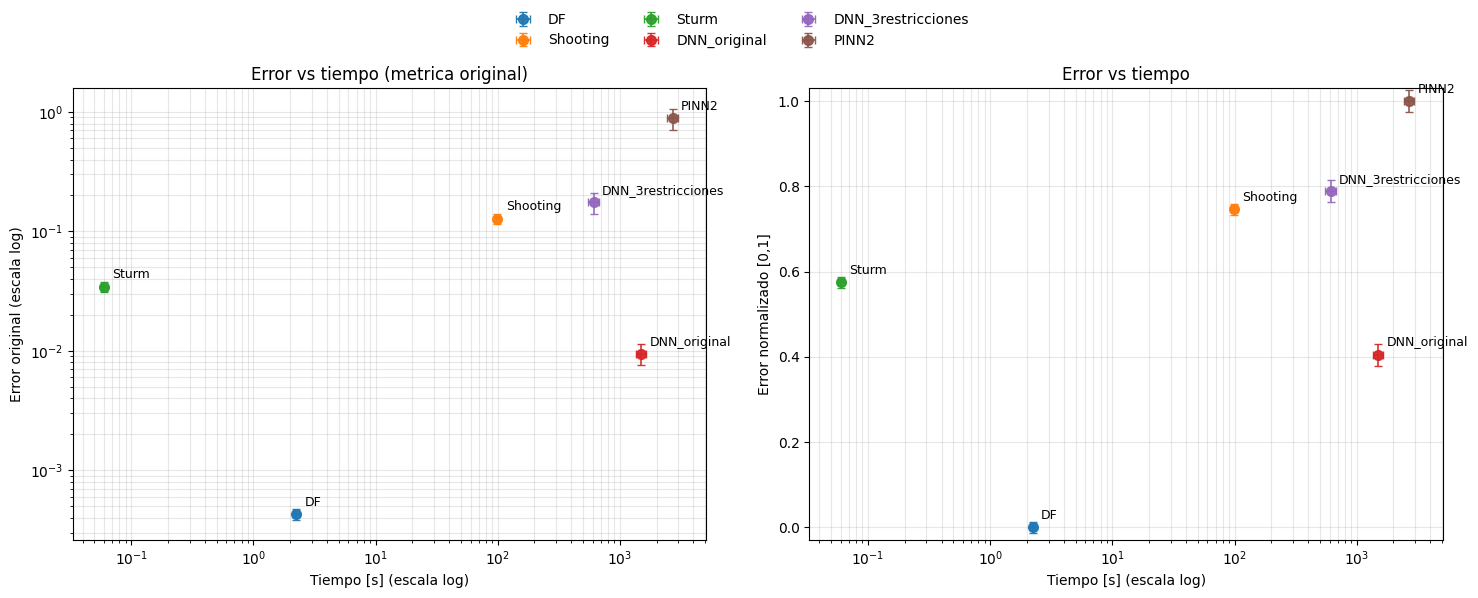


Nota:
Las incertidumbres actuales son estimadas para visualizacion y se pueden reemplazar
por desviaciones estandar reales si repites corridas por metodo.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Datos base
# -----------------------------
# Nota: las metricas originales no son homogeneas entre todos los metodos.
# Para comparacion visual global se calcula tambien una escala unica normalizada.

# Error medio absoluto de Sturm vs DF en eV, usando los deltas compartidos.
delta_sturm_minus_df_eV = np.array([
    -1.425898e-01,
    -3.579107e-02,
    -2.897007e-02,
    -3.686219e-07,
    -1.404269e-07,
    5.033174e-11,
], dtype=float)
err_sturm_mae_eV = float(np.mean(np.abs(delta_sturm_minus_df_eV)))

# Tiempo reportado por el usuario:
# DNN_original = 25 min, PINN2 = 45 min.
# Se agregan incertidumbres estimadas (ajustables) para ambos ejes.
df = pd.DataFrame([
    {
        "metodo": "DF",
        "error_raw": 4.289e-4,
        "time_s": 2.23,
        "error_tipo": "err_rel",
        "err_rel_unc": 0.10,
        "time_rel_unc": 0.05,
    },
    {
        "metodo": "Shooting",
        "error_raw": 1.2776e-1,
        "time_s": 99.39,
        "error_tipo": "err_rel",
        "err_rel_unc": 0.10,
        "time_rel_unc": 0.05,
    },
    {
        "metodo": "Sturm",
        "error_raw": err_sturm_mae_eV,
        "time_s": 0.06,
        "error_tipo": "MAE_eV",
        "err_rel_unc": 0.10,
        "time_rel_unc": 0.05,
    },
    {
        "metodo": "DNN_original",
        "error_raw": 9.443e-3,
        "time_s": 25 * 60,
        "error_tipo": "MAE_test",
        "err_rel_unc": 0.20,
        "time_rel_unc": 0.10,
    },
    {
        "metodo": "DNN_3restricciones",
        "error_raw": 1.7621e-1,
        "time_s": 610.70,
        "error_tipo": "MAE_fisica",
        "err_rel_unc": 0.20,
        "time_rel_unc": 0.10,
    },
    {
        "metodo": "PINN2",
        "error_raw": 8.85e-1,
        "time_s": 45 * 60,
        "error_tipo": "L2_prom",
        "err_rel_unc": 0.20,
        "time_rel_unc": 0.10,
    },
])

# Incertidumbre absoluta por eje (x,y)
df["time_unc_s"] = df["time_s"] * df["time_rel_unc"]
df["error_unc_raw"] = df["error_raw"] * df["err_rel_unc"]

print("Tabla consolidada (error original):")
display(df[["metodo", "error_raw", "error_unc_raw", "error_tipo", "time_s", "time_unc_s"]])

# -----------------------------
# 2) Escala unica para comparar
# -----------------------------
# Se usa normalizacion min-max sobre log10(error) para llevar todo a [0, 1].
# 0 = menor error relativo al conjunto actual, 1 = mayor.
err = df["error_raw"].to_numpy(dtype=float)
log_err = np.log10(np.clip(err, 1e-16, None))
emin, emax = float(np.min(log_err)), float(np.max(log_err))
if np.isclose(emax, emin):
    df["error_norm_0_1"] = 0.0
else:
    df["error_norm_0_1"] = (log_err - emin) / (emax - emin)

# Propagacion simple de incertidumbre hacia la escala normalizada.
# d(norm)/d(log10(e)) = 1/(emax-emin), d(log10(e))/de = 1/(e ln10)
if np.isclose(emax, emin):
    df["error_unc_norm"] = 0.0
else:
    df["error_unc_norm"] = np.abs(
        (1.0 / (emax - emin))
        * (1.0 / (np.clip(df["error_raw"], 1e-16, None) * np.log(10.0)))
        * df["error_unc_raw"]
    )

print("\nTabla con escala unica (error_norm_0_1):")
display(df[["metodo", "error_norm_0_1", "error_unc_norm", "time_s", "time_unc_s"]])

# -----------------------------
# 3) Graficas con color por metodo e incertidumbre en ambos ejes
# -----------------------------
palette = {
    "DF": "tab:blue",
    "Shooting": "tab:orange",
    "Sturm": "tab:green",
    "DNN_original": "tab:red",
    "DNN_3restricciones": "tab:purple",
    "PINN2": "tab:brown",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A) Error original (log-log)
for _, row in df.iterrows():
    c = palette.get(row["metodo"], "tab:gray")
    axes[0].errorbar(
        row["time_s"],
        row["error_raw"],
        xerr=row["time_unc_s"],
        yerr=row["error_unc_raw"],
        fmt="o",
        color=c,
        ecolor=c,
        elinewidth=1.2,
        capsize=3,
        markersize=7,
        alpha=0.95,
        label=row["metodo"],
    )
    axes[0].annotate(
        row["metodo"],
        (row["time_s"], row["error_raw"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Tiempo [s] (escala log)")
axes[0].set_ylabel("Error original (escala log)")
axes[0].set_title("Error vs tiempo (metrica original)")
axes[0].grid(True, which="both", alpha=0.3)

# B) Escala unica normalizada
for _, row in df.iterrows():
    c = palette.get(row["metodo"], "tab:gray")
    axes[1].errorbar(
        row["time_s"],
        row["error_norm_0_1"],
        xerr=row["time_unc_s"],
        yerr=row["error_unc_norm"],
        fmt="o",
        color=c,
        ecolor=c,
        elinewidth=1.2,
        capsize=3,
        markersize=7,
        alpha=0.95,
    )
    axes[1].annotate(
        row["metodo"],
        (row["time_s"], row["error_norm_0_1"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )
axes[1].set_xscale("log")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xlabel("Tiempo [s] (escala log)")
axes[1].set_ylabel("Error normalizado [0,1]")
axes[1].set_title("Error vs tiempo")
axes[1].grid(True, which="both", alpha=0.3)

# Leyenda unica sin duplicados
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
fig.legend(uniq.values(), uniq.keys(), loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

print("\nNota:")
print("Las incertidumbres actuales son estimadas para visualizacion y se pueden reemplazar")
print("por desviaciones estandar reales si repites corridas por metodo.")